In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/Nassau Candy Distributor.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10194, 18)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Lead Time stats:")
print(df['Lead Time'].describe())

Lead Time stats:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


In [5]:
# Create Factory column from Product ID
def get_factory(product_id):
    if 'CHO-MIL' in product_id or 'CHO-NUT' in product_id or 'CHO-SCR' in product_id:
        return "Lot's O' Nuts"
    elif 'CHO-TRI' in product_id or 'CHO-FUD' in product_id:
        return "Wicked Choccy's"
    elif product_id.startswith('SUG'):
        return "Sugar Shack"
    elif 'GOB' in product_id or 'LIC' in product_id or 'GUM' in product_id:
        return "Secret Factory"
    else:
        return "The Other Factory"

df['Factory'] = df['Product ID'].apply(get_factory)

# Create Route column
df['Route'] = df['Factory'] + " → " + df['State/Province']

print("Sample routes:")
print(df['Route'].value_counts().head(10))

Sample routes:
Route
Lot's O' Nuts → California      1175
Wicked Choccy's → California     773
Lot's O' Nuts → New York         680
Lot's O' Nuts → Texas            597
Wicked Choccy's → New York       401
Wicked Choccy's → Texas          360
Lot's O' Nuts → Pennsylvania     320
Lot's O' Nuts → Washington       294
Lot's O' Nuts → Illinois         292
Lot's O' Nuts → Ohio             260
Name: count, dtype: int64


In [6]:
route_stats = df.groupby('Route').agg(
    Total_Shipments=('Lead Time', 'count'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Min_Lead_Time=('Lead Time', 'min'),
    Max_Lead_Time=('Lead Time', 'max')
).reset_index()

route_stats = route_stats.sort_values('Avg_Lead_Time')
print("Top 10 Most Efficient Routes:")
print(route_stats.head(10))

Top 10 Most Efficient Routes:
                               Route  Total_Shipments  Avg_Lead_Time  \
78         Secret Factory → Nebraska                1          906.0   
82       Secret Factory → New Mexico                2          906.0   
126    The Other Factory → Louisiana                1          907.0   
123     The Other Factory → Illinois                1          907.0   
119  The Other Factory → Connecticut                2          907.5   
163          Wicked Choccy's → Maine                2          908.0   
77      Secret Factory → Mississippi                1          908.0   
72        Secret Factory → Louisiana                2          908.5   
90   Secret Factory → South Carolina                1          909.0   
66         Secret Factory → Delaware                1          909.0   

     Min_Lead_Time  Max_Lead_Time  
78             906            906  
82             904            908  
126            907            907  
123            907            907

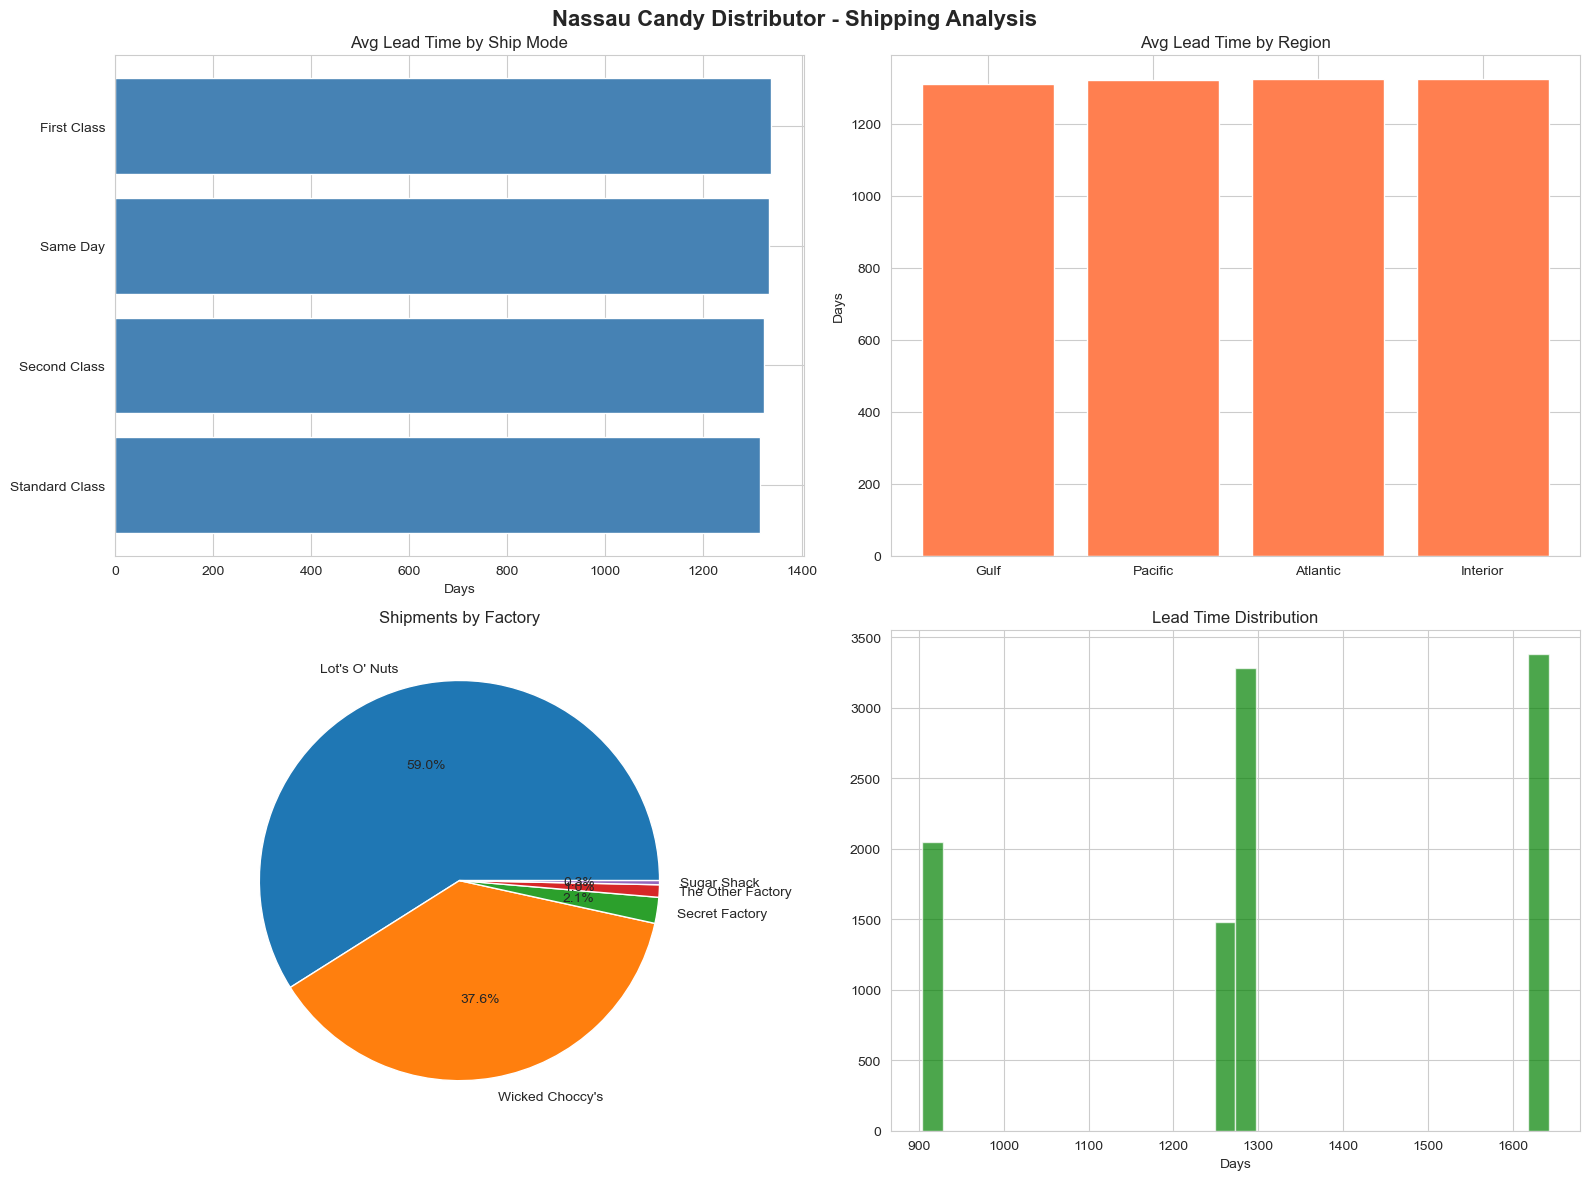

Charts saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Nassau Candy Distributor - Shipping Analysis', fontsize=16, fontweight='bold')

# Chart 1: Avg Lead Time by Ship Mode
ship_mode_avg = df.groupby('Ship Mode')['Lead Time'].mean().sort_values()
axes[0,0].barh(ship_mode_avg.index, ship_mode_avg.values, color='steelblue')
axes[0,0].set_title('Avg Lead Time by Ship Mode')
axes[0,0].set_xlabel('Days')

# Chart 2: Avg Lead Time by Region
region_avg = df.groupby('Region')['Lead Time'].mean().sort_values()
axes[0,1].bar(region_avg.index, region_avg.values, color='coral')
axes[0,1].set_title('Avg Lead Time by Region')
axes[0,1].set_ylabel('Days')

# Chart 3: Shipments by Factory
factory_counts = df['Factory'].value_counts()
axes[1,0].pie(factory_counts.values, labels=factory_counts.index, autopct='%1.1f%%')
axes[1,0].set_title('Shipments by Factory')

# Chart 4: Lead Time Distribution
axes[1,1].hist(df['Lead Time'], bins=30, color='green', alpha=0.7)
axes[1,1].set_title('Lead Time Distribution')
axes[1,1].set_xlabel('Days')

plt.tight_layout()
plt.savefig('../data/eda_charts.png', dpi=150)
plt.show()
print("Charts saved!")

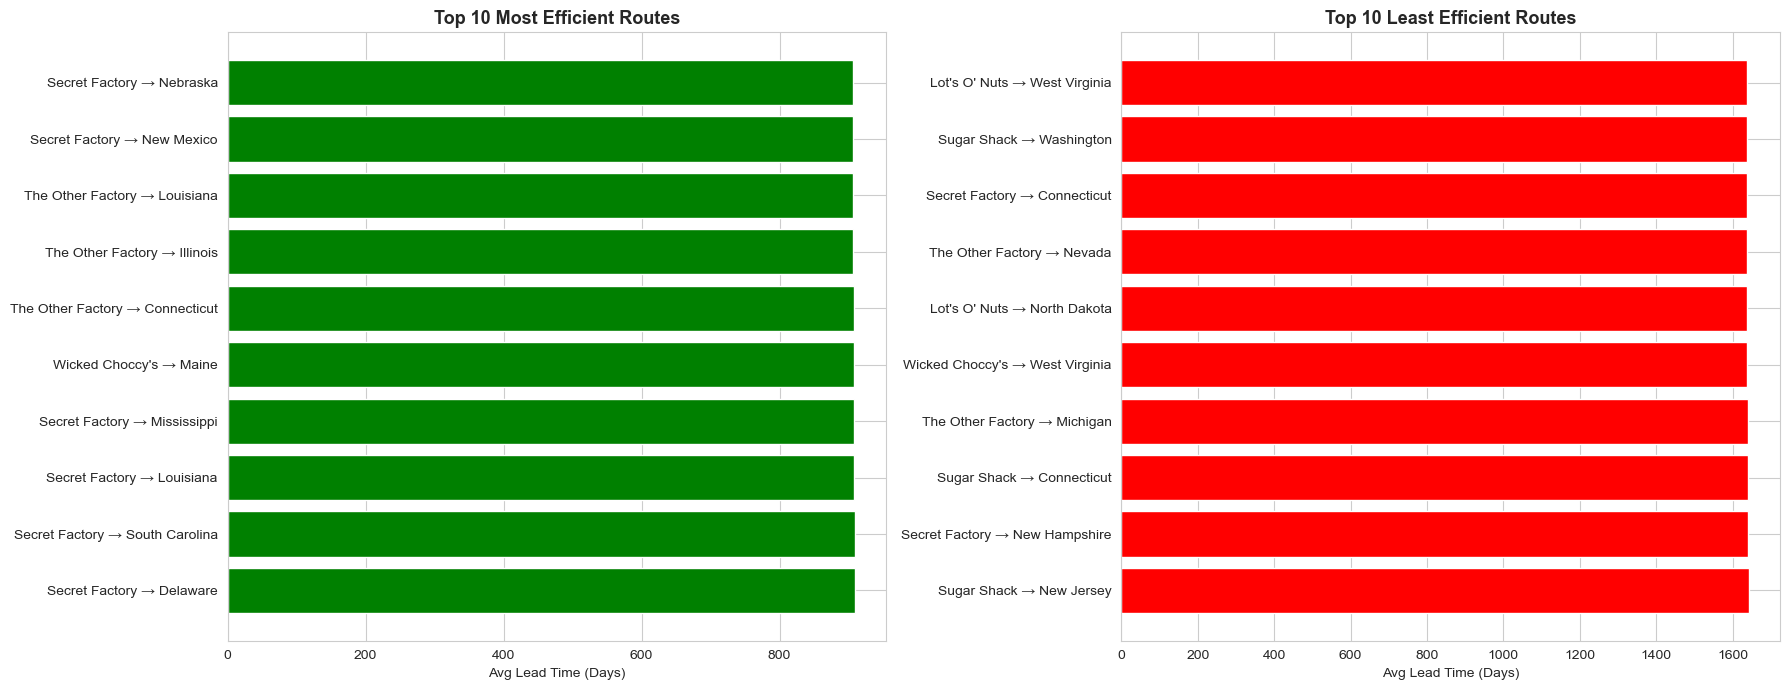

Route chart saved!


In [8]:
# Top 10 most efficient routes
top10 = route_stats.head(10)
bottom10 = route_stats.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Most Efficient
axes[0].barh(top10['Route'], top10['Avg_Lead_Time'], color='green')
axes[0].set_title('Top 10 Most Efficient Routes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Lead Time (Days)')
axes[0].invert_yaxis()

# Least Efficient
axes[1].barh(bottom10['Route'], bottom10['Avg_Lead_Time'], color='red')
axes[1].set_title('Top 10 Least Efficient Routes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Lead Time (Days)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/route_efficiency.png', dpi=150)
plt.show()
print("Route chart saved!")